# Baseline

**Table of contents**<a id='toc0_'></a>    
- [Model Choice](#toc1_1_)    
  - [Problem Geometry](#toc1_2_)    
  - [Implementation](#toc1_3_)    
    - [Heterogenous material problem setup](#toc1_3_1_)    
    - [Homogenous material problem setup](#toc1_3_2_)    
    - [Heat Source](#toc1_3_3_)    
  - [Execution](#toc1_4_)    
  - [Visualization](#toc1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Model Choice](#toc0_)

To get a baseline, and compare the PIN developed, the baseline is a Finite element Mesh method. This is the standard for performing heat transfer analysis, they are simple and reliable, but are very slow to execute.


In [1]:
from fenics import *
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from utils.geometry import Geometry


/home/fernando/miniconda3/envs/fenics_env/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## <a id='toc1_2_'></a>[Problem Geometry](#toc0_)

The geometry of study is a 2D rectangular cross-section with a localized heat source, representing the cross-section of a simplified BJT transistor with power losses in the center.


In [2]:
def estimate_scales(chip, power_loss, k_si, rho_si, cp_si):
    #Thermal Diffusivity (m^2/s)
    alpha = k_si / (rho_si * cp_si)
    #Characteristic Time Scale (tau)
    tau = (chip.ly**2) / alpha   
    #  (dT_scale)
    depth = 0.0005   
    # Distance from the center of the active zone to the bottom sink
    y_center = (chip.active_y_init + chip.active_y_fin) / 2.0   
    # Resistance = distance / (k * Area_cross_section)
    # Area_cs = chip.lx * depth
    thermal_resistance = y_center / (k_si * (chip.lx * depth))
    
    dT_scale = power_loss * thermal_resistance
    
    return tau, dT_scale

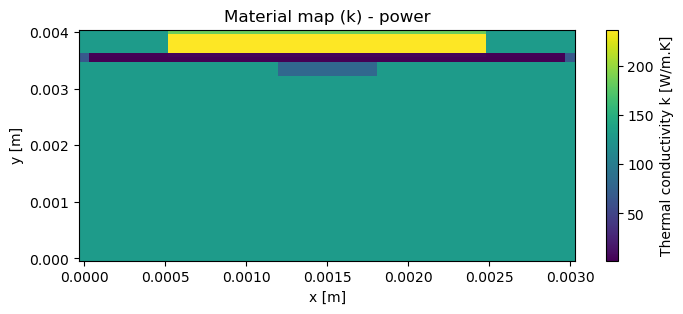

In [3]:

regions_power = {
    # Thick silicon substrate
    "silicon_bulk": {
        "x_init": 0.0, "x_fin": 3.0e-3,
        "y_init": 0.0, "y_fin": 3.5e-3,
        "k": 130.0, "rho": 2330.0, "cp": 700.0
    },

    # Active channel / drift region
    "active": {
        "x_init": 1.2e-3, "x_fin": 1.8e-3,
        "y_init": 3.2e-3, "y_fin": 3.5e-3,
        "k": 80.0, "rho": 2330.0, "cp": 700.0
    },

    # Gate oxide / dielectric
    "oxide": {
        "x_init": 0.0, "x_fin": 3.0e-3,
        "y_init": 3.5e-3, "y_fin": 3.6e-3,
        "k": 1.4, "rho": 2200.0, "cp": 700.0
    },

    # Thick top metallization
    "metal": {
        "x_init": 0.5e-3, "x_fin": 2.5e-3,
        "y_init": 3.6e-3, "y_fin": 4.0e-3,
        "k": 237.0, "rho": 8900.0, "cp": 385.0
    }
}
chip=Geometry(regions=regions_power,lx=3e-3,ly=4e-3,name="power",backend='numpy')
# Material (Silicon)
# We define these as defaults, but we will try to use the mask if available
K_SI = 130.0          # W/(m K)
RHO_SI = 2330.0       # kg/m^3
CP_SI = 700.0         # J/(kg K)

# Power Source
POWER_LOSS = 10.0     # Watts
HOT_SPOT_VOL = chip.hot_spot_volume()#
Q_VOLUMETRIC = POWER_LOSS / HOT_SPOT_VOL # W/m^3  value is 995024875.6218904

rho_cp=RHO_SI*CP_SI


# Diffusion coefficients
dif = K_SI/(RHO_SI*CP_SI)   # This is k / (rho * cp)
A = Q_VOLUMETRIC/(RHO_SI*CP_SI)    # This is Q / (rho * cp)

tau_hat,dT=estimate_scales(chip,POWER_LOSS,K_SI,RHO_SI,CP_SI)
chip.plot_geometry()


## <a id='toc1_3_'></a>[Implementation](#toc0_)
For simulating the Heat equation first we have to set up the map for the conductivity values and the heat values, for this FEA we use fenics.

The IC of the problem is 0K everywhere (simulating temperature rise)
The BC is adiabatic for all walls except the bottom one, bottom is an ideal heatsink



In [4]:
length, height = chip.lx, chip.ly
dx_hat=length/100
dy_hat=dx_hat

nx, ny = 100, int(height//dy_hat)
mesh = RectangleMesh(Point(0, 0), Point(length, height), nx, ny)
V = FunctionSpace(mesh, 'P', 1)

### <a id='toc1_3_1_'></a>[Heterogenous material problem setup](#toc0_)
Here we define the material properties a function that interpolates values from the values previously plotted 

In [5]:


# Parameters & Initial Condition (IC = 0)

k = Function(V)
rho = Function(V)
cp = Function(V)
# Get the physical coordinates of the mesh nodes (DOFs)
dof_coords = V.tabulate_dof_coordinates()  # Shape: [N_nodes, 2]

#Normalize coordinates (internal mask function uses normalized coordinates)
x_norm = (dof_coords[:, 0] / chip.lx) * 2.0 - 1.0
y_norm = (dof_coords[:, 1] / chip.ly) * 2.0 - 1.0
coords_norm = np.stack([x_norm, y_norm], axis=1)


props = chip.material_mask_regions(coords_norm,delta=5e-2)

#Assign the results to the FEniCS Function vectors
k.vector()[:] = props["k"].flatten()
rho.vector()[:] = props["rho"].flatten()
cp.vector()[:] = props["cp"].flatten()





### <a id='toc1_3_2_'></a>[Homogenous material problem setup](#toc0_)


In [ ]:
K_SI = 130.0          # W/(m K)
RHO_SI = 2330.0       # kg/m^3
CP_SI = 700.0  
k   = Constant(K_SI)  # e.g., thermal conductivity (W/m-K)
rho = Constant(RHO_SI) # e.g., density (kg/m^3)
cp  = Constant(CP_SI)  # e.g., specific heat (J/kg-K)



### <a id='toc1_3_3_'></a>[Heat Source](#toc0_)

In [6]:

dt = 1e-3
t_max = tau_hat * 1.5
num_steps = int(t_max // dt)
# Setting Initial Condition to 0.0 everywhere
T_n = interpolate(Constant(0.0), V) 
#Heat Source (Callable Function)
class GaussianSource(UserExpression):
    def __init__(self, geo, t_max, **kwargs):
        super().__init__(**kwargs)
        self.geo = geo
        self.t_max = t_max
        self.t_curr = 0.0
    def eval(self, values, x):
        x_norm = (x[0] / self.geo.lx) * 2.0 - 1.0
        y_norm = (x[1] / self.geo.ly) * 2.0 - 1.0
        t_norm = self.t_curr / self.t_max
        val = self.geo.localized_Q_gaussian(x_norm, y_norm, t_norm, 
                                            Q_max=Q_VOLUMETRIC, 
                                            ramp_t0=10, softness=6)
        values[0] = val
    def value_shape(self):
        return ()
# The Custom Heat Source
f = GaussianSource(chip, t_max, degree=2)

#Boundary Conditions
def bottom_boundary(x, on_boundary):
    return on_boundary and near(x[1], 0)

bc = DirichletBC(V, Constant(0.0), bottom_boundary)

## <a id='toc1_4_'></a>[Execution](#toc0_)

Execution of the FEA code to solve the mesh



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
# Variational Formulation ---

T = TrialFunction(V)
v = TestFunction(V)

# Implicit Euler (Backward Euler) formulation

F = (rho * cp * (T - T_n) / dt * v * dx 
     + k * dot(grad(T), grad(v)) * dx 
     - f * v * dx)

a, L = lhs(F), rhs(F)

# 6. Solution Loop & Data Collection ---
T = Function(V)
t = 0.0

# Storage for PINN and Animation
# We store numpy arrays instead of FEniCS functions to save memory
solution_snapshots = []  # Stores T vector at each step
time_snapshots = []      # Stores time values

# Get coordinates once (for PINN mapping later)
# These align with the indices in T.vector().get_local()
coords = V.tabulate_dof_coordinates() 

print("Starting simulation...")
t_start = time.time()
for n in range(num_steps):
    t += dt
    f.t_curr = t  # Update time in your Heat Source
    
    # Solve
    solve(a == L, T, bc)
    
    # Update previous time step
    T_n.assign(T)
    
    # Save Data:
    # We strip the FEniCS object down to a raw numpy array for storage
    solution_snapshots.append(T.vector().get_local().copy())
    time_snapshots.append(t)
    

    if n % 10 == 0:
        print(f"Step {n}/{num_steps} | Time {t:.3f} | Max T: {T.vector().max():.2f}")

t_finish = time.time()
print(f"Simulation completed in {t_finish - t_start:.2f} seconds.")
# Save Data for PINN (Comparison) ---
#  .npz file containing Coords, Time, and Temperature Data
solution_matrix = np.array(solution_snapshots) # Shape: (TimeSteps, Nodes)
time_array = np.array(time_snapshots)

np.savez("heat_diffusion_data.npz", 
         coords=coords, 
         time=time_array, 
         solution=solution_matrix)
print("\nData saved to 'heat_diffusion_data.npz' for PINN comparison.")


Starting simulation...
Solving linear variational problem.
Step 0/301 | Time 0.001 | Max T: 0.02
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Step 10/301 | Time 0.011 | Max T: 4.53
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Step 20/301 | Time 0.021 | Max T: 16.67
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational probl

## <a id='toc1_5_'></a>[Visualization](#toc0_)

In [8]:
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

print("Generating GIF animation...")

# Determine Global Scale accurately

global_min = solution_matrix.min()
global_max = solution_matrix.max()

# Setup Matplotlib Figure
fig, ax = plt.subplots(figsize=(7, 5))
x_vals = coords[:, 0]
y_vals = coords[:, 1]

# This ensures both the contour and colorbar use the same mapping
norm = plt.Normalize(vmin=global_min, vmax=global_max)
levels = np.linspace(global_min, global_max, 50)

# Create initial plot
contour = ax.tricontourf(x_vals, y_vals, solution_matrix[0], 
                         levels=levels, cmap="inferno", norm=norm)

# Add Colorbar using the norm from the contour
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label("Temperature")

def update(frame_idx):
    ax.clear()
    vals = solution_matrix[frame_idx]
    current_max = vals.max()
    
    # Re-draw with fixed levels and normalization
    ax.tricontourf(x_vals, y_vals, vals, 
                   levels=levels, cmap="inferno", norm=norm)
    
    ax.set_title(f"Time: {time_snapshots[frame_idx]:.3f} s")
    ax.set_aspect('equal')
    
    # Update the instantaneous max temperature text
    ax.text(0.95, 0.95, f"Max Temp: {current_max:.2f}", 
            transform=ax.transAxes, ha='right', va='top', 
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))
    
    return ax,

ani = animation.FuncAnimation(fig, update, frames=len(time_snapshots), interval=50, blit=False)

# Save to GIF
ani.save('heat_diffusion_het.gif', writer='pillow', fps=20)
plt.close(fig)
print("Animation saved")

Generating GIF animation...
Animation saved
